# London Airbnb Analysis — Sentiment Analysis (VADER)

This notebook runs sentiment analysis on 10,000 sampled London Airbnb reviews using VADER (Valence Aware Dictionary and sEntiment Reasoner).

VADER is better than TextBlob for short reviews because it handles:
- Exclamation marks ("Great!" scores higher than "Great")
- Capital letters ("AMAZING" scores higher than "amazing")
- Informal language and slang

See `04_sentiment_textblob.ipynb` for the TextBlob analysis and `06_sentiment_comparison.ipynb` for a comparison of both methods.

## 1. Import Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

print("Libraries loaded!")

Libraries loaded!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/dq/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 2. Load Reviews

In [2]:
# Load the cleaned reviews data
reviews = pd.read_csv('../data/reviews_clean.csv')

print("Reviews loaded!")
print("Rows:", len(reviews))

/var/folders/2j/d77yjnh176bbf7pmhw8lt2zc0000gq/T/ipykernel_74379/3855834746.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv('../data/reviews_clean.csv')


Reviews loaded!
Rows: 2111024


In [3]:
# Sample 10,000 reviews - same sample as TextBlob for fair comparison
reviews_sample = reviews.sample(10000, random_state=42)

print("Sample size:", len(reviews_sample))

Sample size: 10000


## 3. Test VADER

Before running on the full sample, we will test VADER on some simple examples.

In [4]:
# Create the VADER sentiment analyser
sia = SentimentIntensityAnalyzer()

print("VADER analyser ready!")

VADER analyser ready!


In [5]:
# Test on a positive sentence
review1 = "This place was absolutely amazing, loved every minute!"
score1 = sia.polarity_scores(review1)['compound']
print("Review:", review1)
print("Score:", score1)

Review: This place was absolutely amazing, loved every minute!
Score: 0.8612


In [6]:
# Test on a negative sentence
review2 = "Terrible experience, very dirty and noisy."
score2 = sia.polarity_scores(review2)['compound']
print("Review:", review2)
print("Score:", score2)

Review: Terrible experience, very dirty and noisy.
Score: -0.8051


In [8]:
# Test on a neutral sentence
review3 = "The room was a room."
score3 = sia.polarity_scores(review3)['compound']
print("Review:", review3)
print("Score:", score3)

Review: The room was a room.
Score: 0.0


In [11]:
# Test how VADER handles capitals and exclamation marks
review4 = "ABSOLUTELY AMAZING place, loved every minute!!!"
score4 = sia.polarity_scores(review4)['compound']
print("Review:", review4)
print("Score:", score4)

Review: ABSOLUTELY AMAZING place, loved every minute!!!
Score: 0.9225


## 4. Run VADER on Sample

In [13]:
# Run VADER on each review in the sample
reviews_sample['vader_score'] = reviews_sample['comments'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

print("Done!")
print(reviews_sample['vader_score'].describe())

Done!
count    10000.000000
mean         0.677108
std          0.427207
min         -0.992700
25%          0.599400
50%          0.880500
75%          0.955100
max          0.999100
Name: vader_score, dtype: float64


In [14]:
# Classify each review using VADER thresholds
# VADER recommends: positive > 0.05, negative < -0.05, neutral in between
def get_vader_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

reviews_sample['vader_sentiment'] = reviews_sample['vader_score'].apply(get_vader_sentiment)

print("Sentiment counts:")
print(reviews_sample['vader_sentiment'].value_counts())

Sentiment counts:
vader_sentiment
positive    8373
neutral     1117
negative     510
Name: count, dtype: int64


## 5. Visualise Results

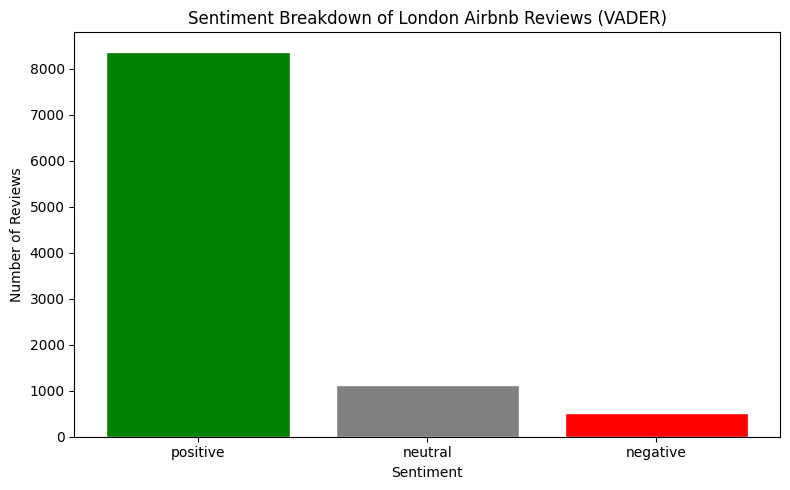

In [15]:
# Plot the VADER sentiment breakdown
sentiment_counts = reviews_sample['vader_sentiment'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'grey', 'red'], edgecolor='white')
plt.title('Sentiment Breakdown of London Airbnb Reviews (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

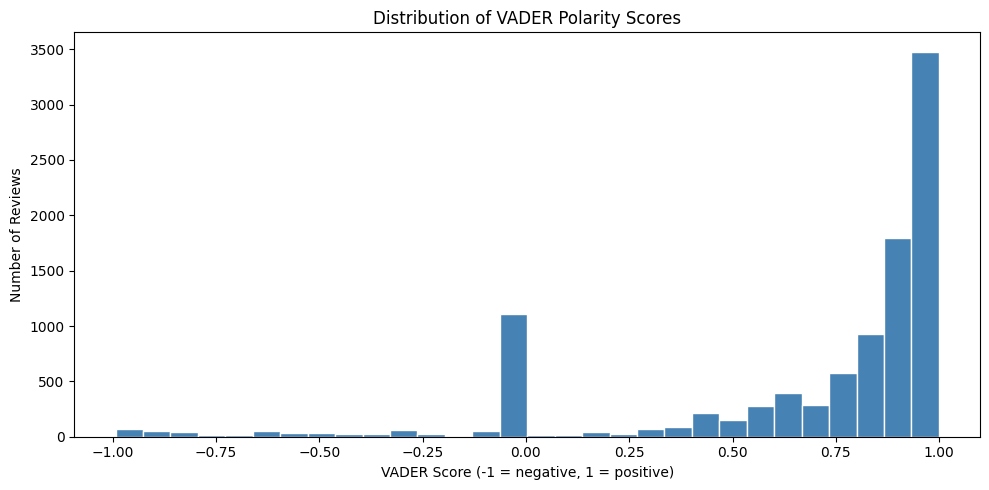

In [16]:
# Plot the distribution of VADER scores
plt.figure(figsize=(10, 5))
plt.hist(reviews_sample['vader_score'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of VADER Polarity Scores')
plt.xlabel('VADER Score (-1 = negative, 1 = positive)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [17]:
# Save the VADER results
reviews_sample.to_csv('../data/reviews_vader.csv', index=False)

print("VADER results saved!")

VADER results saved!


## 7. Summary

Key findings from VADER sentiment analysis on 10,000 sampled London Airbnb reviews:

- **83.7% positive** — the vast majority of guests had a positive experience
- **11.2% neutral** — reviews with no strong positive or negative language
- **5.1% negative** — VADER detected significantly more negative reviews than TextBlob (2%)
- **Average VADER score: 0.68** — strongly positive overall
- **Median score: 0.88** — more than half of reviews score above 0.88, showing most are very positive
- The score distribution is heavily left-skewed with most reviews scoring between 0.6 and 1.0

**Why VADER found more negative reviews than TextBlob:**
- VADER uses a threshold of ±0.05 rather than just above/below zero
- VADER better handles informal language, which can express negativity subtly
- TextBlob missed many mildly negative reviews that VADER correctly identified

**Test results:**
- Positive sentence: 0.86
- Negative sentence: -0.81
- Neutral sentence: 0.0
- Same positive sentence with CAPS and exclamations: 0.92 (higher — as expected)